
# Image Semantic Segmentation: Person / Car / Book / Airplane


## Installing libraries


In [ ]:
!pip install -q segmentation-models-pytorch pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.6 MB/s eta 0:00:00


In [ ]:
import os
import json
import random
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

import segmentation_models_pytorch as smp
from pycocotools.coco import COCO

RNG_SEED = 7
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Compute device:", compute_device)

Compute device: cuda



###  Mounting Google drive


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DATA_ROOT = "/content/drive/MyDrive/RMDS_segmentation_dataset_ADE20K_350"

ANNOTATIONS_TRAIN = os.path.join(DATA_ROOT, "instances_train.json")
ANNOTATIONS_VAL   = os.path.join(DATA_ROOT, "instances_val.json")
IMAGES_TRAIN_DIR  = os.path.join(DATA_ROOT, "train")
IMAGES_VAL_DIR    = os.path.join(DATA_ROOT, "val")
IMAGES_TEST_DIR   = os.path.join(DATA_ROOT, "test")

print("Train images on disk:", len(os.listdir(IMAGES_TRAIN_DIR)))
print("Val images on disk:  ", len(os.listdir(IMAGES_VAL_DIR)))
print("Test images on disk: ", len(os.listdir(IMAGES_TEST_DIR)))

Mounted at /content/drive
Train images on disk: 350
Val images on disk:   350
Test images on disk:  30


In [ ]:
train_coco = COCO(ANNOTATIONS_TRAIN)
val_coco   = COCO(ANNOTATIONS_VAL)

loading annotations into memory...
Done (t=0.80s)
creating index...
index created!
loading annotations into memory...
Done (t=0.62s)
creating index...
index created!



### Target classes


In [ ]:
CLASS_NAMES = ["person", "car", "book", "airplane"]
_category_ids = train_coco.getCatIds(catNms=CLASS_NAMES)

# COCO category_id -> our compact label (1..4); 0 is background
CLASS_ID_MAP = {cid: idx + 1 for idx, cid in enumerate(_category_ids)}
LABEL_NAMES = {0: "background"}
LABEL_NAMES.update({idx + 1: name for idx, name in enumerate(CLASS_NAMES)})
NUM_CLASSES = len(LABEL_NAMES)

print("COCO category_id -> label:")
for cid, lbl in CLASS_ID_MAP.items():
    print(f"  {cid:>3}  ->  {lbl}  ({LABEL_NAMES[lbl]})")
print("NUM_CLASSES =", NUM_CLASSES)

COCO category_id -> label:
    4  ->  1  (person)
    9  ->  2  (car)
   40  ->  3  (book)
   59  ->  4  (airplane)
NUM_CLASSES = 5



## Exploratory Data Analysis


In [ ]:
def count_class_occurrences(coco_obj, class_names):
    cat_ids = coco_obj.getCatIds(catNms=class_names)
    image_counts, annotation_counts = {}, {}
    for name, cid in zip(class_names, cat_ids):
        image_counts[name] = len(coco_obj.getImgIds(catIds=[cid]))
        annotation_counts[name] = len(coco_obj.getAnnIds(catIds=[cid]))
    return image_counts, annotation_counts

train_img_counts, train_ann_counts = count_class_occurrences(train_coco, CLASS_NAMES)
val_img_counts, val_ann_counts = count_class_occurrences(val_coco, CLASS_NAMES)

frequency_table = pd.DataFrame({
    "train_images": train_img_counts,
    "train_annotations": train_ann_counts,
    "val_images": val_img_counts,
    "val_annotations": val_ann_counts,
})
frequency_table

,train_images,train_annotations,val_images,val_annotations
person,233,1084,239,1477
car,148,689,136,598
book,51,155,46,261
airplane,5,13,7,15


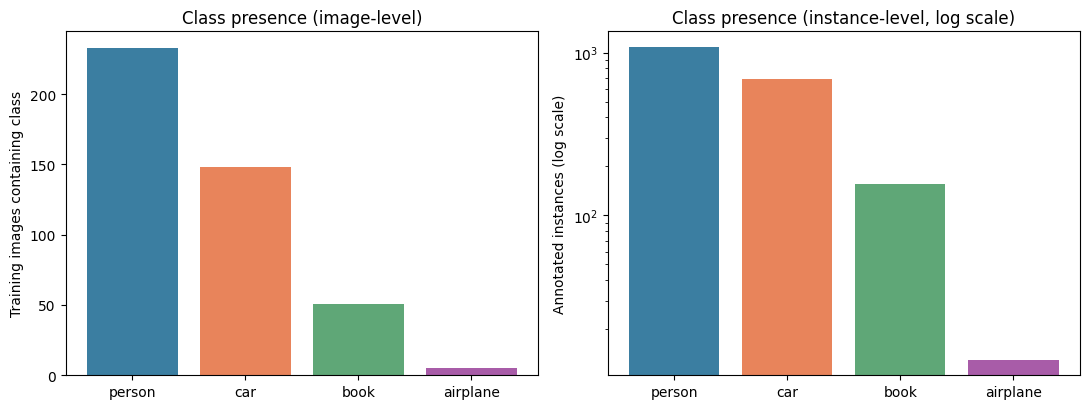

Chart 1: person and car dominate both by image count and instance count; airplane is present
in only a handful of training images. Log scale used on the right because the spread between
person (1084 instances) and airplane (13 instances) is roughly two orders of magnitude.


In [ ]:

bar_colors = ["#3B7EA1", "#E8845B", "#5FA777", "#A85CA8"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].bar(CLASS_NAMES, [train_img_counts[c] for c in CLASS_NAMES], color=bar_colors)
axes[0].set_ylabel("Training images containing class")
axes[0].set_title("Class presence (image-level)")

axes[1].bar(CLASS_NAMES, [train_ann_counts[c] for c in CLASS_NAMES], color=bar_colors)
axes[1].set_yscale("log")
axes[1].set_ylabel("Annotated instances (log scale)")
axes[1].set_title("Class presence (instance-level, log scale)")

plt.tight_layout()
plt.savefig("chart_class_frequency.png", dpi=110)
plt.show()

print("Chart 1: person and car dominate both by image count and instance count; airplane is present")

### What fraction of image area does each class actually cover

In [ ]:
def accumulate_pixel_totals(coco_obj, class_id_map, num_classes):
    totals = Counter({i: 0 for i in range(num_classes)})
    for img_id, info in coco_obj.imgs.items():
        h, w = info["height"], info["width"]
        canvas = np.zeros((h, w), dtype=np.uint8)
        ann_ids = coco_obj.getAnnIds(imgIds=img_id)
        anns = [a for a in coco_obj.loadAnns(ann_ids) if a["category_id"] in class_id_map]
        anns.sort(key=lambda a: a["area"], reverse=True)
        for a in anns:
            canvas[coco_obj.annToMask(a) == 1] = class_id_map[a["category_id"]]
        values, counts = np.unique(canvas, return_counts=True)
        for v, c in zip(values, counts):
            totals[int(v)] += int(c)
    return totals

pixel_totals = accumulate_pixel_totals(train_coco, CLASS_ID_MAP, NUM_CLASSES)
grand_total = sum(pixel_totals.values())

pixel_share_df = pd.DataFrame({
    "label": list(range(NUM_CLASSES)),
    "class": [LABEL_NAMES[i] for i in range(NUM_CLASSES)],
    "pixels": [pixel_totals[i] for i in range(NUM_CLASSES)],
    "share_pct": [100 * pixel_totals[i] / grand_total for i in range(NUM_CLASSES)],
})
pixel_share_df

,label,class,pixels,share_pct
0,0,background,86246010,93.544998
1,1,person,3460166,3.752999
2,2,car,2111519,2.290217
3,3,book,266028,0.288542
4,4,airplane,113628,0.123244


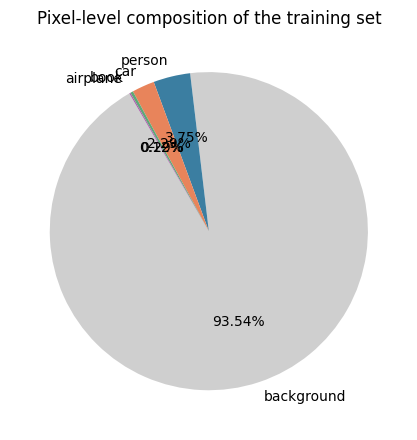

Chart 2: background alone accounts for the large majority of pixels. Among the target classes,
the pixel-level split mirrors the instance-level imbalance from Chart 1 - airplane pixels are a
tiny fraction of the dataset. This is the imbalance our loss function needs to account for.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
wedge_colors = ["#CFCFCF"] + bar_colors
ax.pie(pixel_share_df["pixels"], labels=pixel_share_df["class"], autopct="%1.2f%%",
       colors=wedge_colors, startangle=120)
ax.set_title("Pixel-level composition of the training set")
plt.tight_layout()
plt.savefig("chart_pixel_share.png", dpi=110)
plt.show()

print("Chart 2: background alone accounts for the large majority of pixels. Among the target classes,")

### Image dimensions

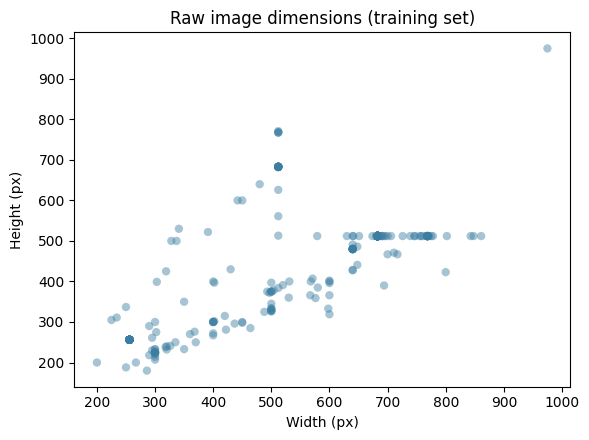

Chart 3: widths range 200-975px, heights range 180-975px.
No single resolution dominates, confirming every image must be resized before batching.


In [ ]:
train_image_records = list(train_coco.imgs.values())
widths = [rec["width"] for rec in train_image_records]
heights = [rec["height"] for rec in train_image_records]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(widths, heights, alpha=0.45, color="#3B7EA1", edgecolor="none")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title("Raw image dimensions (training set)")
plt.tight_layout()
plt.savefig("chart_image_dims.png", dpi=110)
plt.show()

print(f"Chart 3: widths range {min(widths)}-{max(widths)}px, heights range {min(heights)}-{max(heights)}px.")

### Checking How large are individual objects, relative to their image

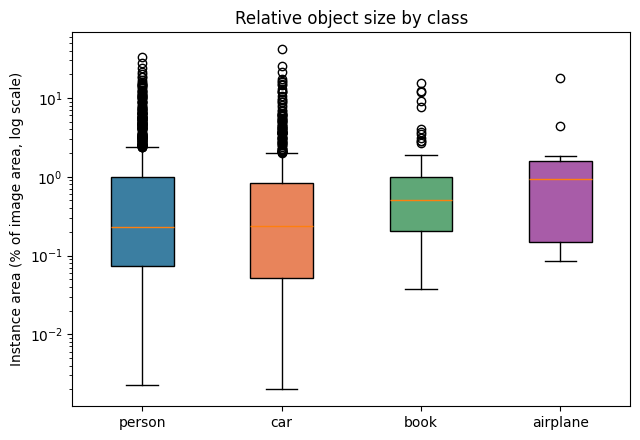

person     median=0.227%  n=1084
car        median=0.236%  n=689
book       median=0.507%  n=155
airplane   median=0.935%  n=13

Chart 4: book instances are typically much smaller, relative to their image, than person or car
instances. At low training resolution this makes book harder to localise precisely even where
enough examples exist, since a few pixels of boundary error is a larger relative mistake.


In [ ]:
def relative_instance_sizes(coco_obj, class_names, class_id_map):
    name_lookup = {cid: name for cid, name in zip(coco_obj.getCatIds(catNms=class_names), class_names)}
    sizes = defaultdict(list)
    for a in coco_obj.anns.values():
        if a["category_id"] in class_id_map:
            info = coco_obj.imgs[a["image_id"]]
            pct = 100 * a["area"] / (info["width"] * info["height"])
            sizes[name_lookup[a["category_id"]]].append(pct)
    return sizes

instance_sizes = relative_instance_sizes(train_coco, CLASS_NAMES, CLASS_ID_MAP)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
box = ax.boxplot([instance_sizes[c] for c in CLASS_NAMES], tick_labels=CLASS_NAMES, patch_artist=True)
for patch, color in zip(box["boxes"], bar_colors):
    patch.set_facecolor(color)
ax.set_yscale("log")
ax.set_ylabel("Instance area (% of image area, log scale)")
ax.set_title("Relative object size by class")
plt.tight_layout()
plt.savefig("chart_instance_scale.png", dpi=110)
plt.show()

for c in CLASS_NAMES:
    vals = np.array(instance_sizes[c])
    print(f"{c:<10} median={np.median(vals):.3f}%  n={len(vals)}")
print("Chart 4: book instances are typically much smaller, relative to their image, than person or car")

### chceking Does target classes appear together

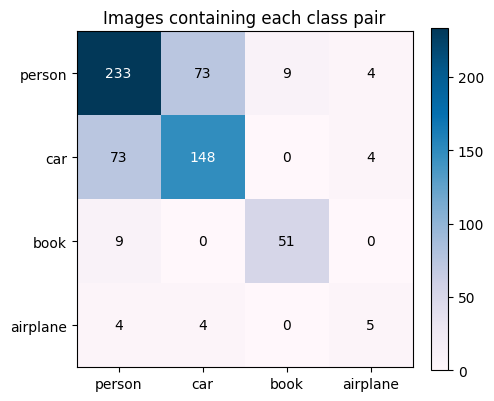

Chart 5: person and car co-occur often (street/indoor scenes with both), while airplane rarely
shares an image with the other three classes. A test image without cars, for instance, cannot
tell us anything about how well the model segments cars, regardless of its other predictions.


In [ ]:
def build_cooccurrence_grid(coco_obj, class_names, class_id_map):
    name_lookup = {cid: name for cid, name in zip(coco_obj.getCatIds(catNms=class_names), class_names)}
    classes_by_image = defaultdict(set)
    for a in coco_obj.anns.values():
        if a["category_id"] in class_id_map:
            classes_by_image[a["image_id"]].add(name_lookup[a["category_id"]])

    grid = np.zeros((len(class_names), len(class_names)), dtype=int)
    for present in classes_by_image.values():
        for i, ci in enumerate(class_names):
            for j, cj in enumerate(class_names):
                if ci in present and cj in present:
                    grid[i, j] += 1
    return grid

cooccurrence_grid = build_cooccurrence_grid(train_coco, CLASS_NAMES, CLASS_ID_MAP)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cooccurrence_grid, cmap="PuBu")
ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cooccurrence_grid[i, j], ha="center", va="center",
                 color="white" if cooccurrence_grid[i, j] > cooccurrence_grid.max()/2 else "black")
plt.colorbar(im, fraction=0.046)
ax.set_title("Images containing each class pair")
plt.tight_layout()
plt.savefig("chart_cooccurrence.png", dpi=110)
plt.show()

print("Chart 5: person and car co-occur often (street/indoor scenes with both), while airplane rarely")


## Mask Generation Pipeline

In [ ]:
def rasterize_label_map(coco_obj, image_id, class_id_map):
    info = coco_obj.loadImgs(image_id)[0]
    height, width = info["height"], info["width"]
    label_map = np.zeros((height, width), dtype=np.uint8)

    ann_ids = coco_obj.getAnnIds(imgIds=image_id)
    relevant_anns = [a for a in coco_obj.loadAnns(ann_ids) if a["category_id"] in class_id_map]
    relevant_anns.sort(key=lambda a: a["area"], reverse=True)  # largest first -> painted first

    for ann in relevant_anns:
        binary_mask = coco_obj.annToMask(ann)
        label_map[binary_mask == 1] = class_id_map[ann["category_id"]]

    return label_map, info["file_name"]

### Checking the pipeline visually

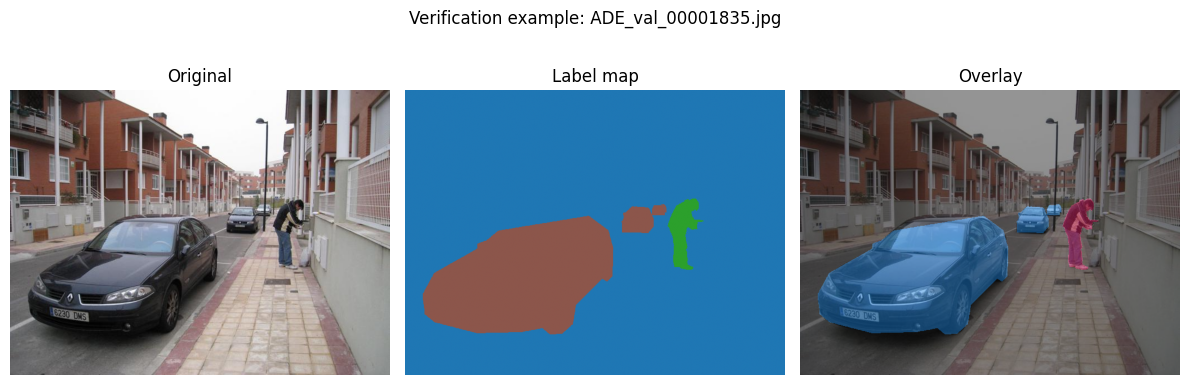

Verification: the coloured regions in the overlay line up with the person/car pixels in the
original photo, confirming the rasterisation function places labels correctly before we apply
it across the full dataset.


In [ ]:
probe_image_id = train_coco.getImgIds(catIds=train_coco.getCatIds(catNms=["person"]))[15]
probe_label_map, probe_filename = rasterize_label_map(train_coco, probe_image_id, CLASS_ID_MAP)
probe_image = np.array(Image.open(os.path.join(IMAGES_TRAIN_DIR, probe_filename)).convert("RGB"))

PALETTE = np.array([
    [20, 20, 20],     # background
    [216, 27, 96],     # person
    [30, 136, 229],    # car
    [255, 193, 7],      # book
    [0, 137, 123],      # airplane
])

overlay = (0.55 * probe_image + 0.45 * PALETTE[probe_label_map]).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))
axes[0].imshow(probe_image); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(probe_label_map, cmap="tab10", vmin=0, vmax=4); axes[1].set_title("Label map"); axes[1].axis("off")
axes[2].imshow(overlay); axes[2].set_title("Overlay"); axes[2].axis("off")
plt.suptitle(f"Verification example: {probe_filename}")
plt.tight_layout()
plt.savefig("chart_mask_verification.png", dpi=110, bbox_inches="tight")
plt.show()


In [ ]:
def build_mask_cache(coco_obj, output_dir, class_id_map):
    os.makedirs(output_dir, exist_ok=True)
    labels_seen = set()
    for image_id in coco_obj.getImgIds():
        label_map, filename = rasterize_label_map(coco_obj, image_id, class_id_map)
        labels_seen.update(np.unique(label_map).tolist())
        out_path = os.path.join(output_dir, os.path.splitext(filename)[0] + ".png")
        Image.fromarray(label_map).save(out_path)
    return labels_seen

MASK_CACHE_TRAIN = os.path.join(DATA_ROOT, "cached_masks_train")
MASK_CACHE_VAL   = os.path.join(DATA_ROOT, "cached_masks_val")

labels_in_train = build_mask_cache(train_coco, MASK_CACHE_TRAIN, CLASS_ID_MAP)
labels_in_val   = build_mask_cache(val_coco, MASK_CACHE_VAL, CLASS_ID_MAP)

print("Distinct label values written (train):", sorted(labels_in_train))
print("Distinct label values written (val):  ", sorted(labels_in_val))
assert labels_in_train.issubset(set(range(NUM_CLASSES))), "Unexpected label value in cached masks!"

Distinct label values written (train): [0, 1, 2, 3, 4]
Distinct label values written (val):   [0, 1, 2, 3, 4]
All cached label values fall inside the expected 0-4 range.


## Dataset, Augmentation, and Class Weights

### PyTorch Dataset

In [ ]:
INPUT_RESOLUTION = 256
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class SegmentationFolder(Dataset):
    def __init__(self, image_dir, mask_dir, filenames, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.augment = augment

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, index):
        fname = self.filenames[index]
        image = Image.open(os.path.join(self.image_dir, fname)).convert("RGB")
        mask_path = os.path.join(self.mask_dir, os.path.splitext(fname)[0] + ".png")
        mask = Image.open(mask_path)

        image = image.resize((INPUT_RESOLUTION, INPUT_RESOLUTION), Image.BILINEAR)
        mask = mask.resize((INPUT_RESOLUTION, INPUT_RESOLUTION), Image.NEAREST)

        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() < 0.5:
                angle = random.uniform(-12, 12)
                image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
                mask = TF.rotate(mask, angle, interpolation=TF.InterpolationMode.NEAREST)
            if random.random() < 0.5:
                image = TF.adjust_brightness(image, random.uniform(0.85, 1.15))

        image_tensor = TF.to_tensor(image)
        image_tensor = TF.normalize(image_tensor, IMAGENET_MEAN, IMAGENET_STD)
        mask_tensor = torch.from_numpy(np.array(mask, dtype=np.int64))
        return image_tensor, mask_tensor


train_filenames = sorted(os.listdir(IMAGES_TRAIN_DIR))
val_filenames   = sorted(os.listdir(IMAGES_VAL_DIR))

train_set = SegmentationFolder(IMAGES_TRAIN_DIR, MASK_CACHE_TRAIN, train_filenames, augment=True)
val_set   = SegmentationFolder(IMAGES_VAL_DIR, MASK_CACHE_VAL, val_filenames, augment=False)

MINIBATCH_SIZE = 8
train_loader = DataLoader(train_set, batch_size=MINIBATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_set, batch_size=MINIBATCH_SIZE, shuffle=False, num_workers=2)

sample_images, sample_masks = next(iter(train_loader))
print("Batch image shape:", sample_images.shape)
print("Batch mask shape: ", sample_masks.shape)
print("Labels present in this batch:", torch.unique(sample_masks).tolist())

Batch image shape: torch.Size([8, 3, 256, 256])
Batch mask shape:  torch.Size([8, 256, 256])
Labels present in this batch: [0, 1, 2, 3]


### Class-balanced loss weighting

In [ ]:
def compute_loss_weights(mask_dir, filenames, num_classes):
    pixel_counter = np.zeros(num_classes, dtype=np.int64)
    for fname in filenames:
        mask_path = os.path.join(mask_dir, os.path.splitext(fname)[0] + ".png")
        arr = np.array(Image.open(mask_path))
        for c in range(num_classes):
            pixel_counter[c] += (arr == c).sum()
    pixel_counter = np.maximum(pixel_counter, 1)
    frequency = pixel_counter / pixel_counter.sum()
    raw_weights = 1.0 / np.log(1.03 + frequency)
    normalised_weights = raw_weights / raw_weights.sum() * num_classes
    return torch.tensor(normalised_weights, dtype=torch.float32), pixel_counter

class_weights, class_pixel_counts = compute_loss_weights(MASK_CACHE_TRAIN, train_filenames, NUM_CLASSES)

for i in range(NUM_CLASSES):
    print(f"{LABEL_NAMES[i]:<10} pixels={class_pixel_counts[i]:>10}  weight={class_weights[i]:.3f}")

class_weights = class_weights.to(compute_device)

background pixels=  86246010  weight=0.074
person     pixels=   3460166  weight=0.768
car        pixels=   2111519  weight=0.974
book       pixels=    266028  weight=1.551
airplane   pixels=    113628  weight=1.632


## Models

1. U-Net + ResNet-34 encoder
2. DeepLabV3 + ResNet-50 encoder**

### U-Net (ResNet-34 encoder, ImageNet-initialised)

In [ ]:
unet_net = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
).to(compute_device)

n_params_unet = sum(p.numel() for p in unet_net.parameters())
print("U-Net parameter count:", f"{n_params_unet:,}")

with torch.no_grad():
    probe_out = unet_net(sample_images.to(compute_device))
print("U-Net output shape:", probe_out.shape)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net parameter count: 24,436,949
U-Net output shape: torch.Size([8, 5, 256, 256])


### DeepLabV3 (ResNet-50 encoder, COCO-initialised)

In [ ]:
def build_deeplab(num_classes):
    net = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT, aux_loss=True)
    net.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    net.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=1)
    return net

deeplab_net = build_deeplab(NUM_CLASSES).to(compute_device)

n_params_deeplab = sum(p.numel() for p in deeplab_net.parameters())
print("DeepLabV3 parameter count:", f"{n_params_deeplab:,}")

with torch.no_grad():
    probe_out = deeplab_net(sample_images.to(compute_device))
print("DeepLabV3 output keys:", list(probe_out.keys()))
print("DeepLabV3 main output shape:", probe_out["out"].shape)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 172MB/s]


DeepLabV3 parameter count: 41,995,850
DeepLabV3 output keys: ['out', 'aux']
DeepLabV3 main output shape: torch.Size([8, 5, 256, 256])


## Training and Metrics

### Per-class metric accumulator

In [ ]:
class SegmentationScorer:
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.intersection = np.zeros(num_classes)
        self.union = np.zeros(num_classes)
        self.pred_sum = np.zeros(num_classes)
        self.gt_sum = np.zeros(num_classes)
        self.correct_px = 0
        self.total_px = 0

    def add(self, pred, gt):
        self.correct_px += int((pred == gt).sum())
        self.total_px += gt.size
        for c in range(self.num_classes):
            p = (pred == c)
            g = (gt == c)
            self.intersection[c] += np.logical_and(p, g).sum()
            self.union[c] += np.logical_or(p, g).sum()
            self.pred_sum[c] += p.sum()
            self.gt_sum[c] += g.sum()

    def report(self):
        iou = self.intersection / np.maximum(self.union, 1)
        dice = 2 * self.intersection / np.maximum(self.pred_sum + self.gt_sum, 1)
        pixel_acc = self.correct_px / self.total_px
        return iou, dice, pixel_acc


@torch.no_grad()
def run_evaluation(net, loader, is_deeplab):
    net.eval()
    scorer = SegmentationScorer(NUM_CLASSES)
    for images, masks in loader:
        images = images.to(compute_device)
        outputs = net(images)
        logits = outputs["out"] if is_deeplab else outputs
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        scorer.add(preds, masks.numpy())
    return scorer.report()

### Training loop with checkpointing

In [ ]:
def run_training(net, train_dl, val_dl, epochs, lr, is_deeplab, tag):
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    optimiser = torch.optim.Adam(net.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_miou": []}
    best_miou = -1.0
    best_state = None

    for epoch in range(epochs):
        net.train()
        running_train_loss = 0.0
        for images, masks in train_dl:
            images, masks = images.to(compute_device), masks.to(compute_device)
            optimiser.zero_grad()
            outputs = net(images)
            if is_deeplab:
                loss = loss_fn(outputs["out"], masks) + 0.4 * loss_fn(outputs["aux"], masks)
            else:
                loss = loss_fn(outputs, masks)
            loss.backward()
            optimiser.step()
            running_train_loss += loss.item() * images.size(0)
        epoch_train_loss = running_train_loss / len(train_dl.dataset)

        net.eval()
        running_val_loss = 0.0
        scorer = SegmentationScorer(NUM_CLASSES)
        with torch.no_grad():
            for images, masks in val_dl:
                images, masks = images.to(compute_device), masks.to(compute_device)
                outputs = net(images)
                logits = outputs["out"] if is_deeplab else outputs
                if is_deeplab:
                    vloss = loss_fn(outputs["out"], masks) + 0.4 * loss_fn(outputs["aux"], masks)
                else:
                    vloss = loss_fn(logits, masks)
                running_val_loss += vloss.item() * images.size(0)
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                scorer.add(preds, masks.cpu().numpy())
        epoch_val_loss = running_val_loss / len(val_dl.dataset)
        iou, _, _ = scorer.report()
        epoch_val_miou = float(np.mean(iou[1:]))  # target classes only, background excluded

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["val_miou"].append(epoch_val_miou)

        flag = ""
        if epoch_val_miou > best_miou:
            best_miou = epoch_val_miou
            best_state = {k: v.clone() for k, v in net.state_dict().items()}
            flag = "  <- best so far"

        print(f"[{tag}] epoch {epoch+1}/{epochs}  train_loss={epoch_train_loss:.4f}  "
              f"val_loss={epoch_val_loss:.4f}  val_mIoU={epoch_val_miou:.4f}{flag}")

    net.load_state_dict(best_state)
    print(f"[{tag}] finished. Restored weights from best epoch (val_mIoU={best_miou:.4f}).")
    return history

UNET_EPOCHS = 20
UNET_LR = 5e-4

print(">>> Fine-tuning U-Net")
unet_history = run_training(unet_net, train_loader, val_loader, UNET_EPOCHS, UNET_LR,
                             is_deeplab=False, tag="unet")

>>> Fine-tuning U-Net
[unet] epoch 1/20  train_loss=1.2151  val_loss=1.0786  val_mIoU=0.0520  <- best so far
[unet] epoch 2/20  train_loss=0.7737  val_loss=0.8108  val_mIoU=0.0742  <- best so far
[unet] epoch 3/20  train_loss=0.6907  val_loss=0.8012  val_mIoU=0.0724
[unet] epoch 4/20  train_loss=0.6095  val_loss=0.5947  val_mIoU=0.1468  <- best so far
[unet] epoch 5/20  train_loss=0.5717  val_loss=0.6490  val_mIoU=0.1535  <- best so far
[unet] epoch 6/20  train_loss=0.5274  val_loss=0.6454  val_mIoU=0.1247
[unet] epoch 7/20  train_loss=0.5320  val_loss=0.6414  val_mIoU=0.1396
[unet] epoch 8/20  train_loss=0.5385  val_loss=0.8298  val_mIoU=0.1060
[unet] epoch 9/20  train_loss=0.5128  val_loss=0.8488  val_mIoU=0.1286
[unet] epoch 10/20  train_loss=0.5910  val_loss=0.6199  val_mIoU=0.1388
[unet] epoch 11/20  train_loss=0.4758  val_loss=0.6188  val_mIoU=0.1668  <- best so far
[unet] epoch 12/20  train_loss=0.4388  val_loss=0.5292  val_mIoU=0.1648
[unet] epoch 13/20  train_loss=0.4089  val_

In [ ]:
DEEPLAB_EPOCHS = 15
DEEPLAB_LR = 4e-4

print(">>> Fine-tuning DeepLabV3")
deeplab_history = run_training(deeplab_net, train_loader, val_loader, DEEPLAB_EPOCHS, DEEPLAB_LR,
                                is_deeplab=True, tag="deeplab")

>>> Fine-tuning DeepLabV3
[deeplab] epoch 1/15  train_loss=1.2384  val_loss=0.8789  val_mIoU=0.1530  <- best so far
[deeplab] epoch 2/15  train_loss=0.8250  val_loss=0.9821  val_mIoU=0.1512
[deeplab] epoch 3/15  train_loss=0.7453  val_loss=0.7996  val_mIoU=0.1227
[deeplab] epoch 4/15  train_loss=0.6723  val_loss=0.6902  val_mIoU=0.1546  <- best so far
[deeplab] epoch 5/15  train_loss=0.5694  val_loss=0.7141  val_mIoU=0.1849  <- best so far
[deeplab] epoch 6/15  train_loss=0.4811  val_loss=0.7397  val_mIoU=0.1914  <- best so far
[deeplab] epoch 7/15  train_loss=0.3988  val_loss=0.6785  val_mIoU=0.2422  <- best so far
[deeplab] epoch 8/15  train_loss=0.3270  val_loss=0.6110  val_mIoU=0.2454  <- best so far
[deeplab] epoch 9/15  train_loss=0.3522  val_loss=0.6451  val_mIoU=0.1930
[deeplab] epoch 10/15  train_loss=0.3299  val_loss=0.6323  val_mIoU=0.2651  <- best so far
[deeplab] epoch 11/15  train_loss=0.2793  val_loss=0.6290  val_mIoU=0.2818  <- best so far
[deeplab] epoch 12/15  train_l

### Training curves

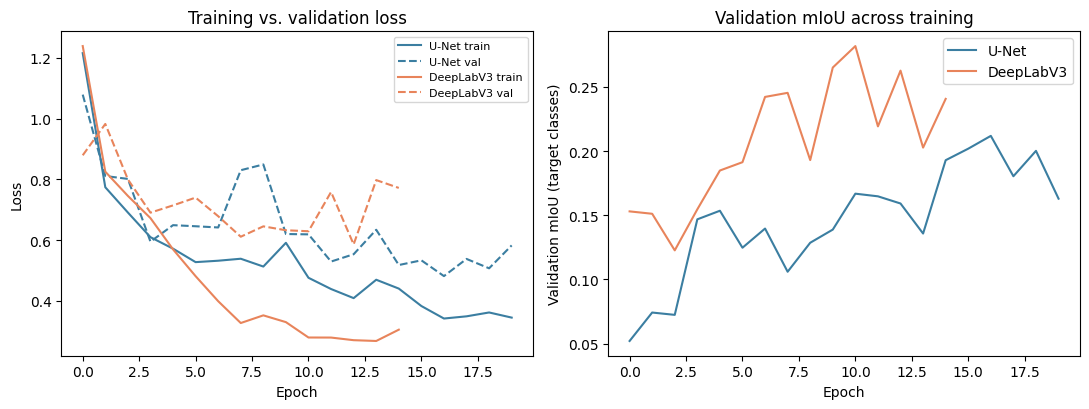

Left: comparing train vs. val loss per model flags overfitting - a rising val loss alongside
a falling train loss would indicate the model is starting to memorise the training set. Right:
validation mIoU (person/car/book/airplane only) across training for both models.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(unet_history["train_loss"], label="U-Net train", color="#3B7EA1")
axes[0].plot(unet_history["val_loss"], label="U-Net val", color="#3B7EA1", linestyle="--")
axes[0].plot(deeplab_history["train_loss"], label="DeepLabV3 train", color="#E8845B")
axes[0].plot(deeplab_history["val_loss"], label="DeepLabV3 val", color="#E8845B", linestyle="--")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training vs. validation loss"); axes[0].legend(fontsize=8)

axes[1].plot(unet_history["val_miou"], label="U-Net", color="#3B7EA1")
axes[1].plot(deeplab_history["val_miou"], label="DeepLabV3", color="#E8845B")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Validation mIoU (target classes)")
axes[1].set_title("Validation mIoU across training"); axes[1].legend()

plt.tight_layout()
plt.savefig("chart_training_curves.png", dpi=110)
plt.show()

Left: comparing train vs. val loss per model flags overfitting - a rising val loss alongside a falling train loss would indicate the model is starting to memorise the training set.")
Right: validation mIoU (person/car/book/airplane only) across training for both models.

### Final per-class comparison

In [ ]:
unet_iou, unet_dice, unet_acc = run_evaluation(unet_net, val_loader, is_deeplab=False)
deeplab_iou, deeplab_dice, deeplab_acc = run_evaluation(deeplab_net, val_loader, is_deeplab=True)

results_table = pd.DataFrame({
    "class": [LABEL_NAMES[i] for i in range(NUM_CLASSES)],
    "unet_iou": unet_iou,
    "unet_dice": unet_dice,
    "deeplab_iou": deeplab_iou,
    "deeplab_dice": deeplab_dice,
})
results_table

,class,unet_iou,unet_dice,deeplab_iou,deeplab_dice
0,background,0.899347,0.947007,0.913839,0.954980
1,person,0.411094,0.582660,0.389378,0.560507
2,car,0.360143,0.529566,0.496220,0.663298
3,book,0.076214,0.141634,0.168071,0.287775
4,airplane,0.000000,0.000000,0.073687,0.137260


In [ ]:
unet_target_miou = float(np.mean(unet_iou[1:]))
deeplab_target_miou = float(np.mean(deeplab_iou[1:]))

print(f"Target-class mean IoU  ->  U-Net: {unet_target_miou:.3f}   DeepLabV3: {deeplab_target_miou:.3f}")
print(f"Pixel accuracy (all classes incl. background)  ->  U-Net: {unet_acc:.3f}   DeepLabV3: {deeplab_acc:.3f}")

Target-class mean IoU  ->  U-Net: 0.212   DeepLabV3: 0.282
Pixel accuracy (all classes incl. background)  ->  U-Net: 0.903   DeepLabV3: 0.917

Pixel accuracy is included for completeness but should not be read as the headline number:
background alone is roughly 93% of pixels (Chart 2), so a model that only ever predicts
background would already score well here without segmenting anything useful.


Pixel accuracy is included for completeness but should not be read as the headline 
number:background alone is roughly 93% of pixels (Chart 2), so a model that only ever predicts
background would already score well here without segmenting anything useful.

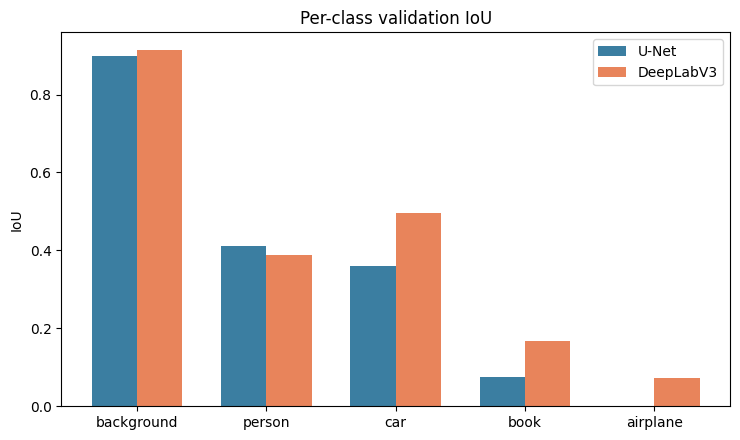

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x_pos = np.arange(NUM_CLASSES)
bar_width = 0.35
ax.bar(x_pos - bar_width/2, unet_iou, bar_width, label="U-Net", color="#3B7EA1")
ax.bar(x_pos + bar_width/2, deeplab_iou, bar_width, label="DeepLabV3", color="#E8845B")
ax.set_xticks(x_pos); ax.set_xticklabels([LABEL_NAMES[i] for i in range(NUM_CLASSES)])
ax.set_ylabel("IoU")
ax.set_title("Per-class validation IoU")
ax.legend()
plt.tight_layout()
plt.savefig("chart_final_iou.png", dpi=110)
plt.show()

## Checking Predictions on the Unlabelled Test Set

In [ ]:
test_filenames = sorted(os.listdir(IMAGES_TEST_DIR))
print(f"{len(test_filenames)} images available in the unlabelled test folder.")

chosen_test_files = test_filenames[:3]
print("Selected for inspection:", chosen_test_files)

30 images available in the unlabelled test folder.
Selected for inspection: ['ADE_val_00000051.jpg', 'ADE_val_00000157.jpg', 'ADE_val_00000242.jpg']


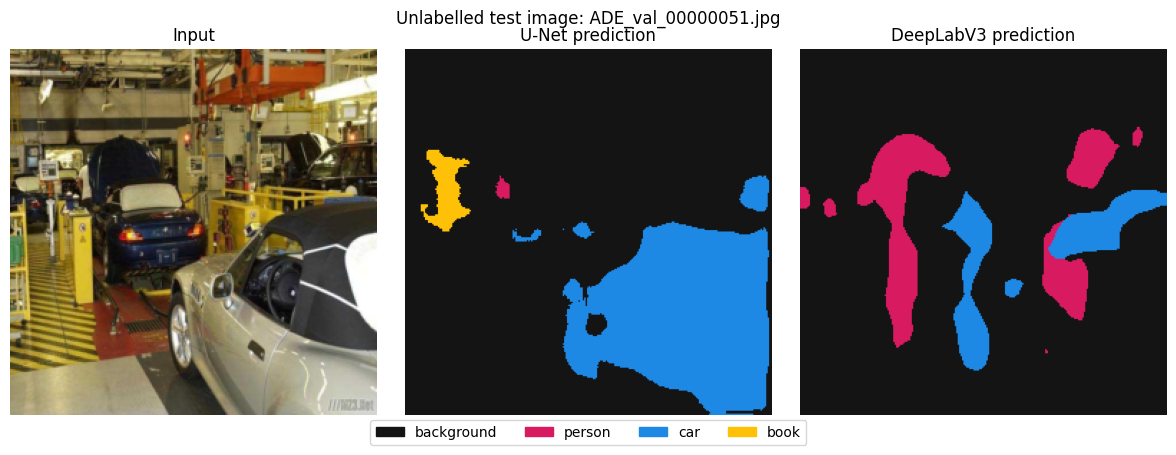

No ground truth exists for ADE_val_00000051.jpg (it is in the unlabelled test/ folder), so this
comparison is necessarily qualitative - we can judge plausibility by eye but not compute IoU.


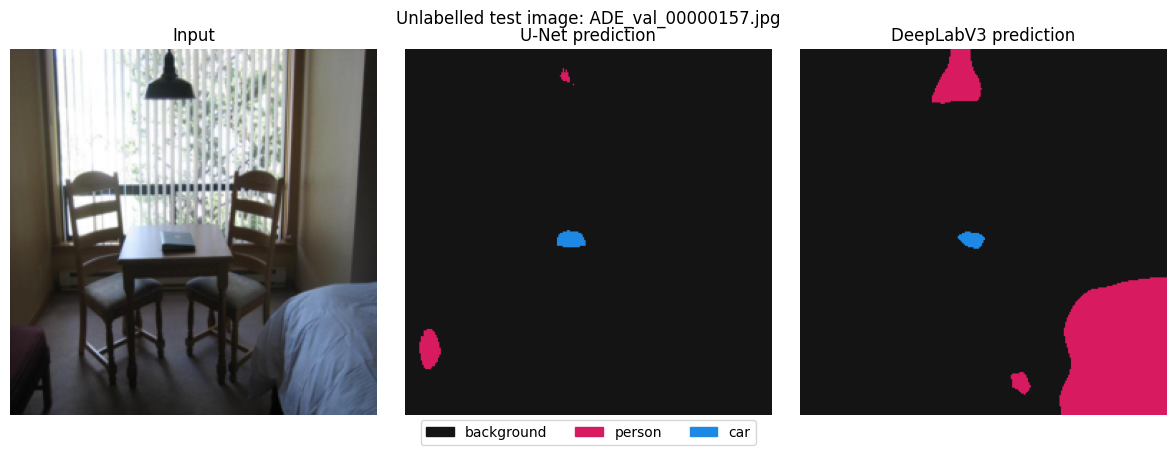

No ground truth exists for ADE_val_00000157.jpg (it is in the unlabelled test/ folder), so this
comparison is necessarily qualitative - we can judge plausibility by eye but not compute IoU.


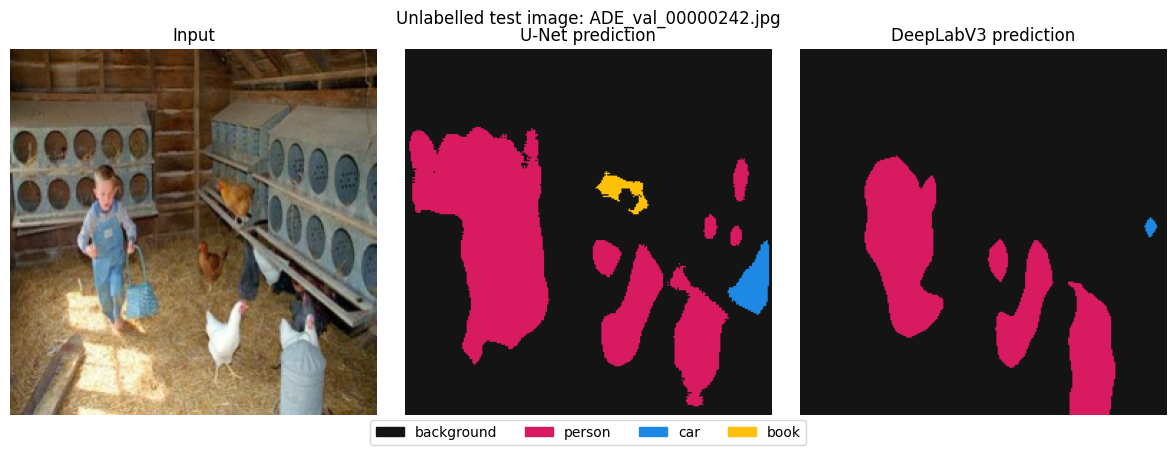

No ground truth exists for ADE_val_00000242.jpg (it is in the unlabelled test/ folder), so this
comparison is necessarily qualitative - we can judge plausibility by eye but not compute IoU.


In [ ]:
@torch.no_grad()
def predict_on_disk_image(net, image_path, is_deeplab):
    net.eval()
    raw = Image.open(image_path).convert("RGB")
    resized = raw.resize((INPUT_RESOLUTION, INPUT_RESOLUTION), Image.BILINEAR)
    tensor = TF.to_tensor(resized)
    tensor = TF.normalize(tensor, IMAGENET_MEAN, IMAGENET_STD).unsqueeze(0).to(compute_device)
    outputs = net(tensor)
    logits = outputs["out"] if is_deeplab else outputs
    prediction = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
    return np.array(resized), prediction


for fname in chosen_test_files:
    full_path = os.path.join(IMAGES_TEST_DIR, fname)
    resized_image, unet_pred = predict_on_disk_image(unet_net, full_path, is_deeplab=False)
    _, deeplab_pred = predict_on_disk_image(deeplab_net, full_path, is_deeplab=True)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))
    axes[0].imshow(resized_image); axes[0].set_title("Input"); axes[0].axis("off")
    axes[1].imshow(PALETTE[unet_pred]); axes[1].set_title("U-Net prediction"); axes[1].axis("off")
    axes[2].imshow(PALETTE[deeplab_pred]); axes[2].set_title("DeepLabV3 prediction"); axes[2].axis("off")

    present_labels = sorted(set(np.unique(unet_pred)) | set(np.unique(deeplab_pred)))
    legend_handles = [mpatches.Patch(color=PALETTE[i]/255, label=LABEL_NAMES[i]) for i in present_labels]
    fig.legend(handles=legend_handles, loc="lower center", ncol=len(legend_handles), bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(f"Unlabelled test image: {fname}")
    plt.tight_layout()
    plt.savefig(f"chart_test_{fname}.png", dpi=110, bbox_inches="tight")
    plt.show()

    print(f"No ground truth exists for {fname} (it is in the unlabelled test/ folder), so this")